<a href="https://colab.research.google.com/github/Ismot10/Disaster-Management-and-Early-Warning-System-App/blob/main/fused_landslide_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1 — Install + Imports

!pip install -q pandas numpy scikit-learn matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
# Cell 2 — Upload + Load Dataset

df = pd.read_csv("fused_landslide_training_dataset.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (3069, 17)


,ts_land,pressure,soil_moisture,landslide_detected,land_risk_num,land_risk_level,water_level_cm,rain_intensity_percent,water_sensor_percent,flood_detected,flood_risk_num,motion,vibration_detected,earthquake_detected,eq_risk_num,water_motion_interaction,rain_soil_interaction
0,2026-02-18 17:04:08,429,2416,0,0,Low,87.454012,18.513293,26.170568,0,1,0.005,0,0,0,0.437270,44728.115607
1,Unknown,417,2384,0,0,Low,145.071431,54.190095,24.697880,0,1,0.004,0,0,0,0.580286,129189.185855
2,2026-02-18 17:04:27,446,2406,0,0,Low,123.199394,87.294584,90.625458,0,3,0.559,0,0,2,68.868461,210030.768112
3,2026-02-18 17:04:31,433,2413,0,0,Low,109.865848,73.222489,24.954620,0,2,0.623,0,0,2,68.446424,176685.865091
4,2026-02-18 17:04:36,432,2413,0,0,Low,65.601864,80.656115,27.194973,0,2,0.001,0,0,0,0.065602,194623.204979


In [ ]:
# Cell 3 — Set Features and Label (4-class)

feature_cols = [
    "pressure","soil_moisture",
    "water_level_cm","rain_intensity_percent","water_sensor_percent",
    "flood_detected","flood_risk_num",
    "motion","vibration_detected","earthquake_detected","eq_risk_num",
    "water_motion_interaction","rain_soil_interaction"
]

# Clean
df2 = df.dropna(subset=feature_cols + ["land_risk_num"]).copy()

X = df2[feature_cols].astype(float).values
y = df2["land_risk_num"].astype(int).values  # 0..3

print("Class counts (0=Low,1=Medium,2=High,3=Critical):")
print(pd.Series(y).value_counts().sort_index())

Class counts (0=Low,1=Medium,2=High,3=Critical):
0    1029
1     885
2    1028
3     127
Name: count, dtype: int64


In [ ]:
# Cell 4 — Train/Test Split (Stratified) + Scale

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = MinMaxScaler()
X_train_n = scaler.fit_transform(X_train)
X_test_n  = scaler.transform(X_test)

In [ ]:
# Cell 5 — Train Random Forest (Balanced)

model = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train_n, y_train)
pred = model.predict(X_test_n)

✅ Accuracy: 80.13 %

✅ Classification Report:
              precision    recall  f1-score   support

         Low       0.86      0.74      0.79       206
      Medium       0.83      0.91      0.87       177
        High       0.74      0.86      0.80       206
    Critical       0.33      0.04      0.07        25

    accuracy                           0.80       614
   macro avg       0.69      0.64      0.63       614
weighted avg       0.79      0.80      0.79       614

✅ Confusion Matrix (raw counts):
 [[152  24  30   0]
 [  6 161  10   0]
 [ 18   8 178   2]
 [  1   0  23   1]]


<Figure size 700x600 with 0 Axes>

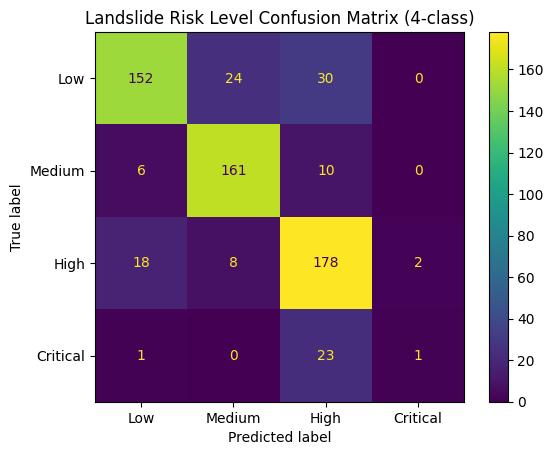

In [ ]:
# Cell 6 — Accuracy + Report + Confusion Matrix (Plot)

labels = [0, 1, 2, 3]
names  = ["Low", "Medium", "High", "Critical"]

acc = accuracy_score(y_test, pred)
print("✅ Accuracy:", round(acc * 100, 2), "%\n")

print("✅ Classification Report:")
print(classification_report(
    y_test, pred,
    labels=labels,
    target_names=names,
    zero_division=0
))

cm = confusion_matrix(y_test, pred, labels=labels)
print("✅ Confusion Matrix (raw counts):\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=names)
plt.figure(figsize=(7,6))
disp.plot(values_format="d")
plt.title("Landslide Risk Level Confusion Matrix (4-class)")
plt.show()

Top 10 important features:
soil_moisture               0.247069
pressure                    0.212672
motion                      0.098827
water_motion_interaction    0.098082
rain_soil_interaction       0.067743
water_level_cm              0.066087
water_sensor_percent        0.063882
rain_intensity_percent      0.059134
eq_risk_num                 0.028173
vibration_detected          0.022694
dtype: float64


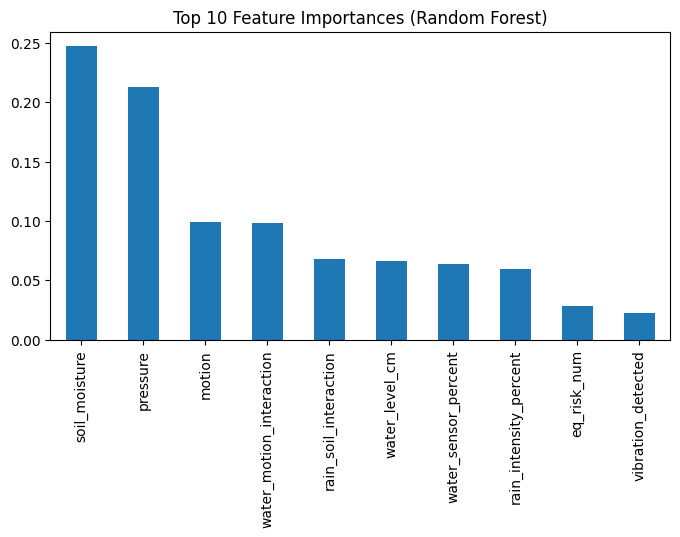

In [ ]:
importances = model.feature_importances_
imp = pd.Series(importances, index=feature_cols).sort_values(ascending=False)

print("Top 10 important features:")
print(imp.head(10))

plt.figure(figsize=(8,4))
imp.head(10).plot(kind="bar")
plt.title("Top 10 Feature Importances (Random Forest)")
plt.show()

✅ Accuracy: 76.71 %

              precision    recall  f1-score   support

         Low       0.85      0.73      0.79       206
      Medium       0.83      0.91      0.87       177
        High       0.72      0.75      0.74       206
    Critical       0.14      0.16      0.15        25

    accuracy                           0.77       614
   macro avg       0.64      0.64      0.64       614
weighted avg       0.77      0.77      0.77       614

Confusion Matrix:
 [[151  24  31   0]
 [  6 161   9   1]
 [ 19   9 155  23]
 [  1   0  20   4]]


<Figure size 700x600 with 0 Axes>

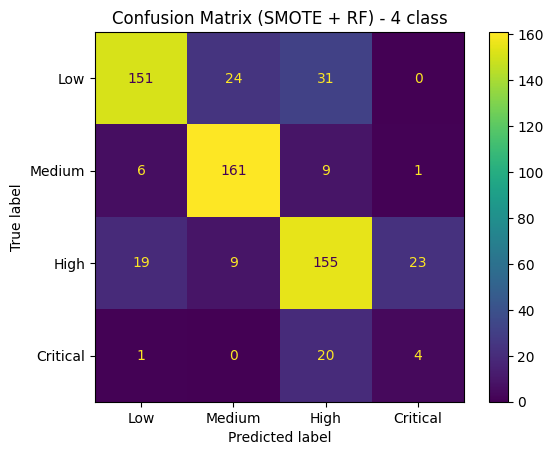

In [ ]:
!pip install -q imbalanced-learn

from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# SMOTE only on train
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_n, y_train)

model = RandomForestClassifier(
    n_estimators=800,
    random_state=42,
    class_weight="balanced"
)
model.fit(X_train_sm, y_train_sm)
pred = model.predict(X_test_n)

labels = [0,1,2,3]
names  = ["Low","Medium","High","Critical"]

print("✅ Accuracy:", round(accuracy_score(y_test, pred)*100, 2), "%\n")
print(classification_report(y_test, pred, labels=labels, target_names=names, zero_division=0))

cm = confusion_matrix(y_test, pred, labels=labels)
print("Confusion Matrix:\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=names)
plt.figure(figsize=(7,6))
disp.plot(values_format="d")
plt.title("Confusion Matrix (SMOTE + RF) - 4 class")
plt.show()

✅ Accuracy: 79.97 %

              precision    recall  f1-score   support

         Low       0.85      0.74      0.79       206
      Medium       0.84      0.90      0.87       177
        High       0.74      0.87      0.80       206
    Critical       0.00      0.00      0.00        25

    accuracy                           0.80       614
   macro avg       0.61      0.63      0.61       614
weighted avg       0.77      0.80      0.78       614



<Figure size 700x600 with 0 Axes>

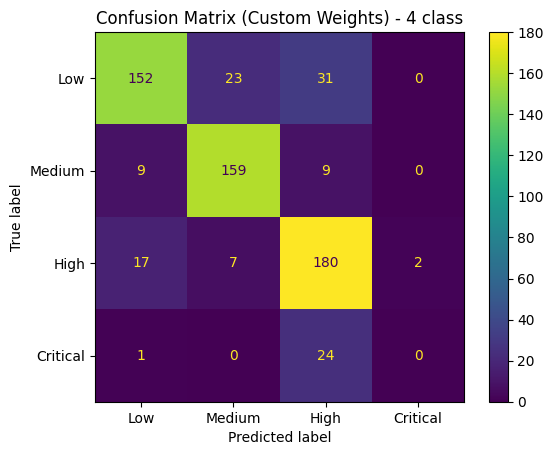

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Heavier weight for Critical (class 3)
class_w = {0: 1.0, 1: 1.2, 2: 1.4, 3: 12.0}

model = RandomForestClassifier(
    n_estimators=800,
    random_state=42,
    class_weight=class_w
)
model.fit(X_train_n, y_train)
pred = model.predict(X_test_n)

labels=[0,1,2,3]
names=["Low","Medium","High","Critical"]

print("✅ Accuracy:", round(accuracy_score(y_test, pred)*100, 2), "%\n")
print(classification_report(y_test, pred, labels=labels, target_names=names, zero_division=0))

cm = confusion_matrix(y_test, pred, labels=labels)
disp = ConfusionMatrixDisplay(cm, display_labels=names)
plt.figure(figsize=(7,6))
disp.plot(values_format="d")
plt.title("Confusion Matrix (Custom Weights) - 4 class")
plt.show()

✅ Accuracy: 77.52 %

              precision    recall  f1-score   support

         Low       0.85      0.74      0.79       206
      Medium       0.84      0.90      0.87       177
        High       0.74      0.77      0.75       206
    Critical       0.22      0.28      0.25        25

    accuracy                           0.78       614
   macro avg       0.66      0.67      0.66       614
weighted avg       0.78      0.78      0.78       614



<Figure size 700x600 with 0 Axes>

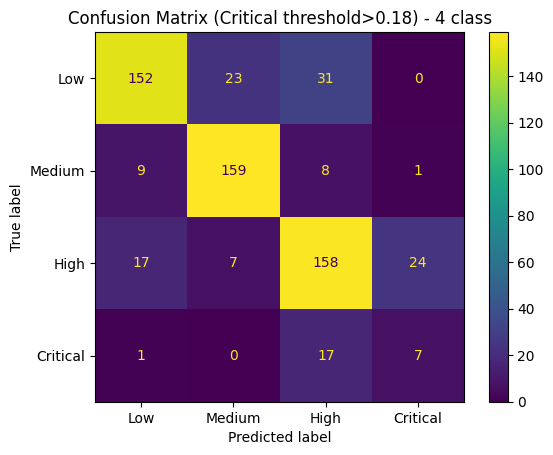

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

proba = model.predict_proba(X_test_n)
pred = np.argmax(proba, axis=1)

T = 0.18  # try 0.15, 0.20, 0.25
pred = np.where(proba[:, 3] > T, 3, pred)

labels=[0,1,2,3]
names=["Low","Medium","High","Critical"]

print("✅ Accuracy:", round(accuracy_score(y_test, pred)*100, 2), "%\n")
print(classification_report(y_test, pred, labels=labels, target_names=names, zero_division=0))

cm = confusion_matrix(y_test, pred, labels=labels)
disp = ConfusionMatrixDisplay(cm, display_labels=names)
plt.figure(figsize=(7,6))
disp.plot(values_format="d")
plt.title(f"Confusion Matrix (Critical threshold>{T}) - 4 class")
plt.show()

Top thresholds by Critical recall (then accuracy):
       T  accuracy  macro_f1  crit_precision  crit_recall   crit_f1  \
1   0.06  0.703583  0.638851        0.182609         0.84  0.300000   
0   0.05  0.687296  0.623566        0.166667         0.84  0.278146   
3   0.08  0.723127  0.651152        0.191489         0.72  0.302521   
2   0.07  0.716612  0.644604        0.180000         0.72  0.288000   
5   0.10  0.739414  0.661562        0.200000         0.64  0.304762   
4   0.09  0.728013  0.650620        0.183908         0.64  0.285714   
6   0.11  0.745928  0.665345        0.205479         0.60  0.306122   
7   0.12  0.744300  0.650383        0.171875         0.44  0.247191   
8   0.13  0.754072  0.657051        0.192308         0.40  0.259740   
11  0.16  0.768730  0.662890        0.210526         0.32  0.253968   

    crit_support  
1             25  
0             25  
3             25  
2             25  
5             25  
4             25  
6             25  
7             2

<Figure size 700x600 with 0 Axes>

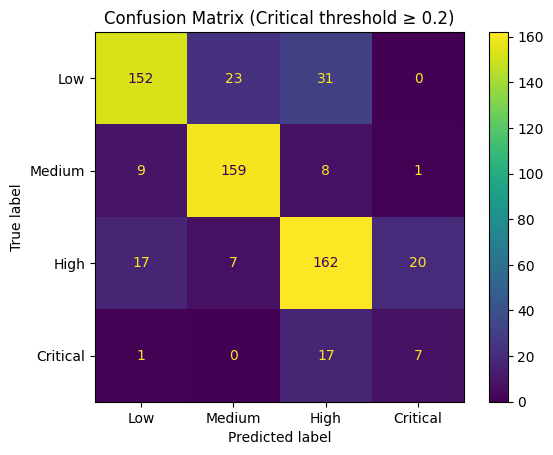

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Get probabilities
proba = model.predict_proba(X_test_n)

def eval_threshold(T):
    # default prediction
    pred = np.argmax(proba, axis=1)

    # force Critical (class 3) if its probability is above threshold
    pred = np.where(proba[:, 3] >= T, 3, pred)

    acc = accuracy_score(y_test, pred)
    prec, rec, f1, sup = precision_recall_fscore_support(
        y_test, pred, labels=[0,1,2,3], zero_division=0
    )
    macro_f1 = f1_score(y_test, pred, average="macro", zero_division=0)

    # Critical metrics are index 3
    return {
        "T": T,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "crit_precision": prec[3],
        "crit_recall": rec[3],
        "crit_f1": f1[3],
        "crit_support": sup[3],
    }

results = [eval_threshold(T) for T in np.round(np.arange(0.05, 0.51, 0.01), 2)]
res = pd.DataFrame(results)

# Sort by Critical recall first (you can change sorting goal)
print("Top thresholds by Critical recall (then accuracy):")
print(res.sort_values(["crit_recall","accuracy"], ascending=False).head(10))

# Pick a threshold with a reasonable tradeoff (example rule):
# maximize Critical F1 while keeping accuracy >= 0.75
candidates = res[res["accuracy"] >= 0.75].copy()
best = candidates.sort_values("crit_f1", ascending=False).head(1)
print("\nBest (accuracy>=0.75) by Critical F1:")
print(best)

best_T = float(best["T"].iloc[0]) if len(best) else 0.18
print("\nChosen T =", best_T)

# Show confusion matrix for chosen threshold
pred_best = np.argmax(proba, axis=1)
pred_best = np.where(proba[:,3] >= best_T, 3, pred_best)

cm = confusion_matrix(y_test, pred_best, labels=[0,1,2,3])
disp = ConfusionMatrixDisplay(cm, display_labels=["Low","Medium","High","Critical"])
plt.figure(figsize=(7,6))
disp.plot(values_format="d")
plt.title(f"Confusion Matrix (Critical threshold ≥ {best_T})")
plt.show()

In [ ]:
# Predict with Critical threshold = 0.20
T = 0.20
proba = model.predict_proba(X_test_n)
pred = np.argmax(proba, axis=1)
pred = np.where(proba[:, 3] >= T, 3, pred)